# Corpus Pipeline Timing Report

This report documents the wall-clock time of each phase in the multi-document corpus pipeline, run on the default arXiv corpus (5 PDFs from `data/arxiv_pdfs/`).

**Code version:** `e7f9ed0` (branch `ft/multi_doc_comparison`)
**Pipeline config:** `configs/params.yaml` (default)

## Key observations

1. **Extraction dominates** at ~72% of pipeline time. GLiNER inference on 59 segments with 5 parallel workers is the bottleneck.
2. **Taxonomy is the second cost** at ~18%. KeyBERT keyword extraction and spaCy dependency parsing run sequentially per document.
3. **Fetch/parse (docling)** is ~10% of the pipeline. Docling's layout detection (RT-DETR) and table structure recognition (TableFormer) dominate.
4. **Segmentation and merge are negligible** — O(n) in segment/document count.
5. **Novelty is high** (87–90%) — most extracted knowledge is unique to each paper.

## How to reproduce

```bash
cd backend
uv run jupyter notebook reports/corpus_timing.ipynb
```

Or from the CLI (partial timing):

```bash
uv run corpus-demo --verbose
```

!!! note
    The notebook provides more granular timing (per-document taxonomy, segmentation, and extraction) compared to the CLI's aggregated output.

# Corpus Demo — Pipeline Timing Report

This notebook runs the **`corpus-demo`** pipeline on the current default corpus
(the 5 arXiv PDFs under `backend/data/arxiv_pdfs/`) with the current
`backend/configs/params.yaml` and the current code, and records the wall-clock
time of **every pipeline phase**.

This is a **report**, not an experiment: it does not compare approaches or
tune parameters — it captures how long each phase takes on this machine, at
this commit, so future changes can be compared against a fixed baseline.

Phases recorded (mirroring `kgraph.cli.corpus_demo` + `kgraph.corpus.merge`):

| # | Phase | What runs |
|---|-------|-----------|
| 0 | Model load | GLiNER model from `ner.name` |
| 1 | Fetch & parse | docling converts the 5 PDFs into `RawDocument`s |
| 2 | Taxonomy | per-document discovery (KeyBERT seeds → spaCy relations → BFS) |
| 3 | Segmentation | `Segmenter` splits each document into token-bounded segments |
| 4 | Extraction | GLiNER inference over every segment (parallel) |
| 5 | Merge | `_merge_per_document` folds per-doc results into one graph |
| 6 | Summarize | `summarize_corpus` computes common/unique + novelty |
| 7 | Export | `export_corpus_json` |
| 8 | Render | `render_corpus_html` (interactive vis-network HTML) |


## Environment & code version

Records the exact code version (git branch/commit), config, and hardware the
report was produced with, so the timings are reproducible and attributable.

In [1]:
import json
import os
import platform
import subprocess
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import pandas as pd

from kgraph.corpus.merge import (
    CorpusGraphBuilder,
    _merge_per_document,
    summarize_corpus,
    export_corpus_json,
)
from kgraph.corpus.viz import render_corpus_html
from kgraph.graph.config import load_pipeline_config
from kgraph.ingestion.factory import build_data_source


def _find_backend() -> Path:
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / "configs" / "params.yaml").exists():
            return cand
    raise RuntimeError("backend/ root not found")


BACKEND = _find_backend()
REPO_ROOT = BACKEND.parent
os.chdir(BACKEND)  # resolve configs/, data/, models/ exactly like the CLI demos

CONFIG_PATH = str(BACKEND / "configs" / "params.yaml")
REPORT_DIR = BACKEND / "reports" / "output"
REPORT_DIR.mkdir(parents=True, exist_ok=True)


def _git(*args):
    try:
        return subprocess.run(
            ["git", *args], cwd=REPO_ROOT, capture_output=True, text=True, check=True
        ).stdout.strip()
    except Exception:
        return None


env = {
    "git_branch": _git("rev-parse", "--abbrev-ref", "HEAD"),
    "git_commit": _git("rev-parse", "HEAD"),
    "git_short_commit": _git("rev-parse", "--short", "HEAD"),
    "git_dirty": bool(_git("status", "--porcelain")),
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S %Z"),
    "platform": platform.platform(),
    "python": platform.python_version(),
    "cpu_count": os.cpu_count(),
    "cwd": str(BACKEND),
}

config = load_pipeline_config(CONFIG_PATH)
env["config_path"] = CONFIG_PATH
env["data_source"] = config.data_source.model_dump()
env["segmentation"] = config.segmentation.model_dump()
env["thresholds"] = config.thresholds.model_dump()

print(json.dumps(env, indent=2, default=str))


{
  "git_branch": "report/corpus-timing",
  "git_commit": "2d91bd838a0ff66c60fbfc9bcfe8b93044c9410c",
  "git_short_commit": "2d91bd8",
  "git_dirty": true,
  "timestamp": "2026-08-16 19:53:20 CEST",
  "platform": "macOS-26.5.1-arm64-arm-64bit",
  "python": "3.12.13",
  "cpu_count": 10,
  "cwd": "/Users/albertovillamanrique/repositories/kgraph/backend",
  "config_path": "/Users/albertovillamanrique/repositories/kgraph/backend/configs/params.yaml",
  "data_source": {
    "type": "local_files",
    "folder": "data/arxiv_pdfs",
    "file_type": "pdf",
    "query": null,
    "max_results": 100
  },
  "segmentation": {
    "enabled": true,
    "max_tokens": 1024,
    "overlap_tokens": 64,
    "workers": 0
  },
  "thresholds": {
    "entity": 0.5,
    "relation": 0.5
  }
}


## Phase 1 — Fetch & parse (docling)

`build_data_source` resolves to `LocalFileSource` (per `data_source` in
`params.yaml`); `fetch()` converts each PDF with docling and attaches the
`DoclingDocument`. The whole phase is timed.

In [2]:
timings = {}

source = build_data_source(config.data_source)

t0 = time.perf_counter()
documents = source.fetch()
fetch_s = time.perf_counter() - t0

timings["fetch_parse"] = {"total_s": round(fetch_s, 4), "n_documents": len(documents)}

for d in documents:
    print(f"  {d.id}: {len(d.content):,} chars | docling_doc={d.docling_doc is not None}")

print(f"\nPhase 1 — fetch & parse (docling): {fetch_s:.2f}s across {len(documents)} documents")


parsing documents:   0%|          | 0/5 [00:00<?, ?doc/s]

INFO:docling.datamodel.document:detected formats: [<InputFormat.PDF: 'pdf'>]


INFO:docling.document_converter:Going to convert document batch...


INFO:docling.document_converter:Initializing pipeline for StandardPdfPipeline with options hash 5e14ed95d216eb81de4e1e29c82e8fe1


INFO:docling.models.factories.base_factory:Loading plugin 'docling_defaults'


...

INFO:docling.pipeline.base_pipeline:Processing document 2604.04450v1.pdf


INFO:docling.document_converter:Finished converting document 2604.04450v1.pdf in 5.48 sec.


parsing documents: 100%|██████████| 5/5 [00:21<00:00,  4.13s/doc]

parsing documents: 100%|██████████| 5/5 [00:21<00:00,  4.22s/doc]

  2308.13916v5: 29,455 chars | docling_doc=True
  2404.17000v1: 29,467 chars | docling_doc=True
  2408.02377v1: 23,775 chars | docling_doc=True
  2408.13521v1: 27,591 chars | docling_doc=True
  2604.04450v1: 75,444 chars | docling_doc=True

Phase 1 — fetch & parse (docling): 21.08s across 5 documents


## Phase 0 — Model load, then Phase 2 — Taxonomy (per-doc discovery)

`CorpusGraphBuilder.__init__` loads the GLiNER model once (shared by all
segments) — that cost is recorded as phase 0. Then discovery runs per
document (`builder._taxonomy`), timing each document separately.

In [3]:
t0 = time.perf_counter()
builder = CorpusGraphBuilder(CONFIG_PATH, workers=config.segmentation.workers)
model_load_s = time.perf_counter() - t0
timings["model_load"] = {"total_s": round(model_load_s, 4), "model": config.ner.name, "workers": builder.workers}

print(f"Phase 0 — model load ({config.ner.name}): {model_load_s:.2f}s | workers={builder.workers}")

taxonomies = {}
per_doc_taxonomy_s = {}
t0 = time.perf_counter()
for d in documents:
    t = time.perf_counter()
    taxonomies[d.id] = builder._taxonomy(d)
    per_doc_taxonomy_s[d.id] = time.perf_counter() - t

taxonomy_s = time.perf_counter() - t0
timings["taxonomy"] = {
    "total_s": round(taxonomy_s, 4),
    "per_document_s": {k: round(v, 4) for k, v in per_doc_taxonomy_s.items()},
    "label_counts": {d.id: (len(taxonomies[d.id][0]), len(taxonomies[d.id][1])) for d in documents},
}

print(f"Phase 2 — taxonomy (per-doc discovery): {taxonomy_s:.2f}s")


INFO:gliner.model:Loading the following GLiNER type: <class 'gliner.model.UniEncoderSpanRelexGLiNER'>...


INFO:sentence_transformers.base.model:No device provided, using mps


INFO:sentence_transformers.base.model:Loading SentenceTransformer model from models/all-MiniLM-L6-v2.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Phase 0 — model load (models/gliner-relex-large-v0.5): 7.14s | workers=5


Phase 2 — taxonomy (per-doc discovery): 40.48s


## Phase 3 — Segmentation

`builder.segmenter.segment` splits each document into token-bounded,
section-aware segments (docling `HierarchicalChunker` + `Segmenter`), timed
per document.

In [4]:
tasks = []
per_doc_segment_s = {}
t0 = time.perf_counter()
for d in documents:
    t = time.perf_counter()
    segments = builder.segmenter.segment(d)
    per_doc_segment_s[d.id] = time.perf_counter() - t
    tasks.extend((d, seg) for seg in segments)

segment_s = time.perf_counter() - t0
n_segments = len(tasks)
timings["segmentation"] = {
    "total_s": round(segment_s, 4),
    "per_document_s": {k: round(v, 4) for k, v in per_doc_segment_s.items()},
    "n_segments": n_segments,
}

print(f"Phase 3 — segmentation: {segment_s:.2f}s | {n_segments} segments total")


Phase 3 — segmentation: 0.19s | 59 segments total


## Phase 4 — Extraction (GLiNER, parallel)

Replicates the `CorpusGraphBuilder.build` extraction loop (thread pool,
one shared model, `workers` from `segmentation.workers`) and times it. In a
parallel run the per-segment times overlap, so `total_s` is authoritative;
per-segment times are recorded for granularity.

In [5]:
import torch

per_segment_extract_s = {}
per_doc_extract_s = {d.id: 0.0 for d in documents}
per_doc = {}

t0 = time.perf_counter()
if n_segments <= 1 or builder.workers <= 1:
    for d, seg in tasks:
        t = time.perf_counter()
        entities, relations = builder._extract(seg, taxonomies[d.id])
        dt = time.perf_counter() - t
        per_segment_extract_s[f"{d.id}#{seg.index}"] = dt
        per_doc_extract_s[d.id] += dt
        per_doc.setdefault(d.id, ([], []))
        per_doc[d.id][0].extend(entities)
        per_doc[d.id][1].extend(relations)
else:
    torch.set_num_threads(1)
    with ThreadPoolExecutor(max_workers=min(builder.workers, n_segments)) as executor:
        futures = {
            executor.submit(builder._extract, seg, taxonomies[d.id]): (d, seg)
            for d, seg in tasks
        }
        for future in futures:
            d, seg = futures[future]
            t = time.perf_counter()
            entities, relations = future.result()
            dt = time.perf_counter() - t
            per_segment_extract_s[f"{d.id}#{seg.index}"] = dt
            per_doc_extract_s[d.id] += dt
            per_doc.setdefault(d.id, ([], []))
            per_doc[d.id][0].extend(entities)
            per_doc[d.id][1].extend(relations)

extraction_s = time.perf_counter() - t0
timings["extraction"] = {
    "total_s": round(extraction_s, 4),
    "per_document_s": {k: round(v, 4) for k, v in per_doc_extract_s.items()},
    "n_segments": n_segments,
    "note": "Parallel run: per-segment times overlap; total_s is authoritative.",
}

print(f"Phase 4 — GLiNER extraction ({'parallel' if builder.workers > 1 else 'serial'}): {extraction_s:.2f}s")


Phase 4 — GLiNER extraction (parallel): 187.38s


## Phase 5 & 6 — Merge and Summarize

The per-document results are folded into a single provenance graph
(`_merge_per_document`), then `summarize_corpus` computes common/unique nodes
and edges plus per-document novelty.

In [6]:
per_document = [(doc_id, e, r) for doc_id, (e, r) in per_doc.items()]

t0 = time.perf_counter()
graph = _merge_per_document(per_document)
timings["merge"] = {"total_s": round(time.perf_counter() - t0, 4)}

t0 = time.perf_counter()
summary = summarize_corpus(graph, [d.id for d in documents])
timings["summarize"] = {"total_s": round(time.perf_counter() - t0, 4)}

print(f"Phase 5 — merge: {timings['merge']['total_s']:.4f}s")
print(f"Phase 6 — summarize: {timings['summarize']['total_s']:.4f}s")
print(f"Graph: {summary['total_nodes']} nodes, {summary['total_edges']} edges")


Phase 5 — merge: 0.0059s
Phase 6 — summarize: 0.0007s
Graph: 1318 nodes, 255 edges


## Phase 7 & 8 — Export (JSON + interactive HTML)

Same as the CLI: `export_corpus_json` writes the graph (with `docs`
provenance) and `render_corpus_html` writes the vis-network visualization.

In [7]:
export_json = REPORT_DIR / f"corpus_graph_{env['git_short_commit']}.json"
export_html = REPORT_DIR / f"corpus_graph_{env['git_short_commit']}.html"

t0 = time.perf_counter()
data = export_corpus_json(graph, summary, str(export_json))
timings["export_json"] = {"total_s": round(time.perf_counter() - t0, 4)}

t0 = time.perf_counter()
render_corpus_html(data, str(export_html))
timings["render_html"] = {"total_s": round(time.perf_counter() - t0, 4)}

print(f"Phase 7 — export JSON: {timings['export_json']['total_s']:.4f}s -> {export_json}")
print(f"Phase 8 — render HTML: {timings['render_html']['total_s']:.4f}s -> {export_html}")


Phase 7 — export JSON: 0.0137s -> /Users/albertovillamanrique/repositories/kgraph/backend/reports/output/corpus_graph_2d91bd8.json
Phase 8 — render HTML: 0.0030s -> /Users/albertovillamanrique/repositories/kgraph/backend/reports/output/corpus_graph_2d91bd8.html


## Results — phase timings

Total wall-clock time per phase, sorted slowest first. "Pipeline total" sums
phases 1–8 (model load is reported separately).

In [8]:
phase_labels = {
    "fetch_parse": "1. fetch & parse (docling)",
    "taxonomy": "2. taxonomy (per-doc discovery)",
    "segmentation": "3. segmentation",
    "extraction": "4. GLiNER extraction",
    "merge": "5. merge",
    "summarize": "6. summarize",
    "export_json": "7. export JSON",
    "render_html": "8. render HTML",
}

rows = []
for key, label in phase_labels.items():
    rows.append({"phase": label, "seconds": timings[key]["total_s"]})

timing_df = pd.DataFrame(rows)
pipeline_total = timing_df["seconds"].sum()
timing_df["share_%"] = (timing_df["seconds"] / pipeline_total * 100).round(1)
timing_df = timing_df.sort_values("seconds", ascending=False).reset_index(drop=True)
print(f"Pipeline total (phases 1-8): {pipeline_total:.2f}s | model load: {timings['model_load']['total_s']:.2f}s")
timing_df


Pipeline total (phases 1-8): 249.15s | model load: 7.14s


,phase,seconds,share_%
0,4. GLiNER extraction,187.3833,75.2
1,2. taxonomy (per-doc discovery),40.4775,16.2
2,1. fetch & parse (docling),21.0829,8.5
3,3. segmentation,0.1861,0.1
4,7. export JSON,0.0137,0.0
5,5. merge,0.0059,0.0
6,8. render HTML,0.0030,0.0
7,6. summarize,0.0007,0.0


## Visualization — phase timings

Horizontal bar chart of the per-phase wall-clock times (sorted slowest first),
with each phase's share of the pipeline total.

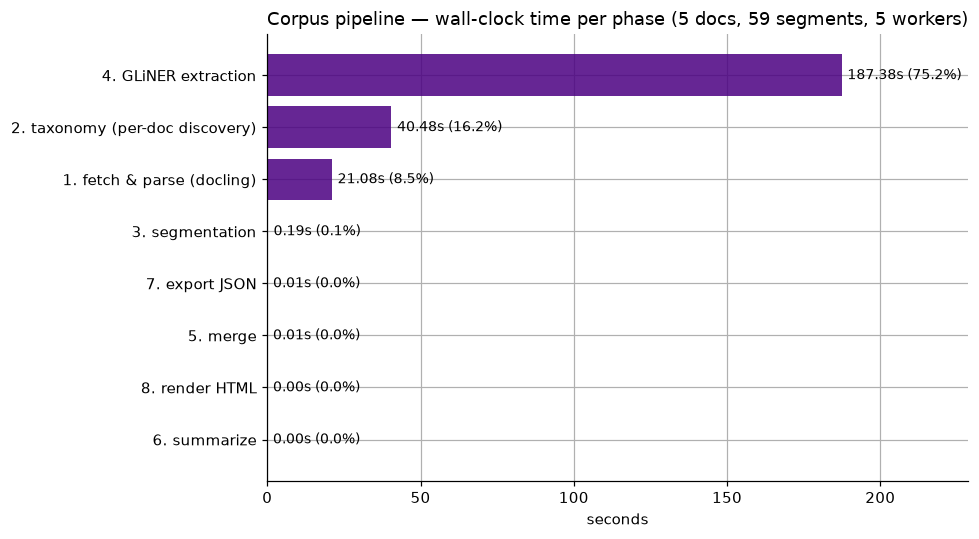

In [9]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

order = timing_df.sort_values("seconds")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(order["phase"], order["seconds"], color="indigo", alpha=0.85)
for y, (_, row) in enumerate(order.iterrows()):
    ax.text(
        row["seconds"] + order["seconds"].max() * 0.01,
        y,
        f"{row['seconds']:.2f}s ({row['share_%']:.1f}%)",
        va="center",
        fontsize=9,
    )
ax.set_xlabel("seconds")
ax.set_title(
    f"Corpus pipeline — wall-clock time per phase "
    f"({len(documents)} docs, {n_segments} segments, {builder.workers} workers)"
)
ax.set_xlim(0, order["seconds"].max() * 1.22)
plt.tight_layout()
plt.show()


## Results — per-document breakdown

Discovery and segmentation are inherently per-document, so their timings are
shown per document, together with the extracted entities/relations and the
document's novelty (share of its nodes unique to it).

In [10]:
doc_rows = []
for d in documents:
    ents, rels = per_doc.get(d.id, ([], []))
    n_seg = sum(1 for (dd, _) in tasks if dd.id == d.id)
    doc_rows.append({
        "document": d.id,
        "chars": len(d.content),
        "segments": n_seg,
        "taxonomy_s": per_doc_taxonomy_s[d.id],
        "segmentation_s": per_doc_segment_s[d.id],
        "extraction_s": per_doc_extract_s[d.id],
        "entities": len(ents),
        "relations": len(rels),
        "novelty_%": summary["per_document"][d.id]["novelty"] * 100,
    })
doc_df = pd.DataFrame(doc_rows)
doc_df["taxonomy_s"] = doc_df["taxonomy_s"].round(3)
doc_df["segmentation_s"] = doc_df["segmentation_s"].round(3)
doc_df["extraction_s"] = doc_df["extraction_s"].round(3)
doc_df["novelty_%"] = doc_df["novelty_%"].round(0)
doc_df


,document,chars,segments,taxonomy_s,segmentation_s,extraction_s,entities,relations,novelty_%
0,2308.13916v5,29455,10,6.552,0.038,38.585,645,36,87.0
1,2404.17000v1,29467,11,8.258,0.032,9.805,577,115,89.0
2,2408.02377v1,23775,8,5.658,0.025,9.053,264,184,90.0
3,2408.13521v1,27591,7,7.094,0.023,28.857,473,71,90.0
4,2604.04450v1,75444,23,12.916,0.068,101.072,692,6,90.0


## Visualization — per-document breakdown

Two views of where the time goes per document: a stacked bar of the
taxonomy/segmentation/extraction phases, and a scatter of extraction time
against document length (GLiNER cost scales with the number of segments).

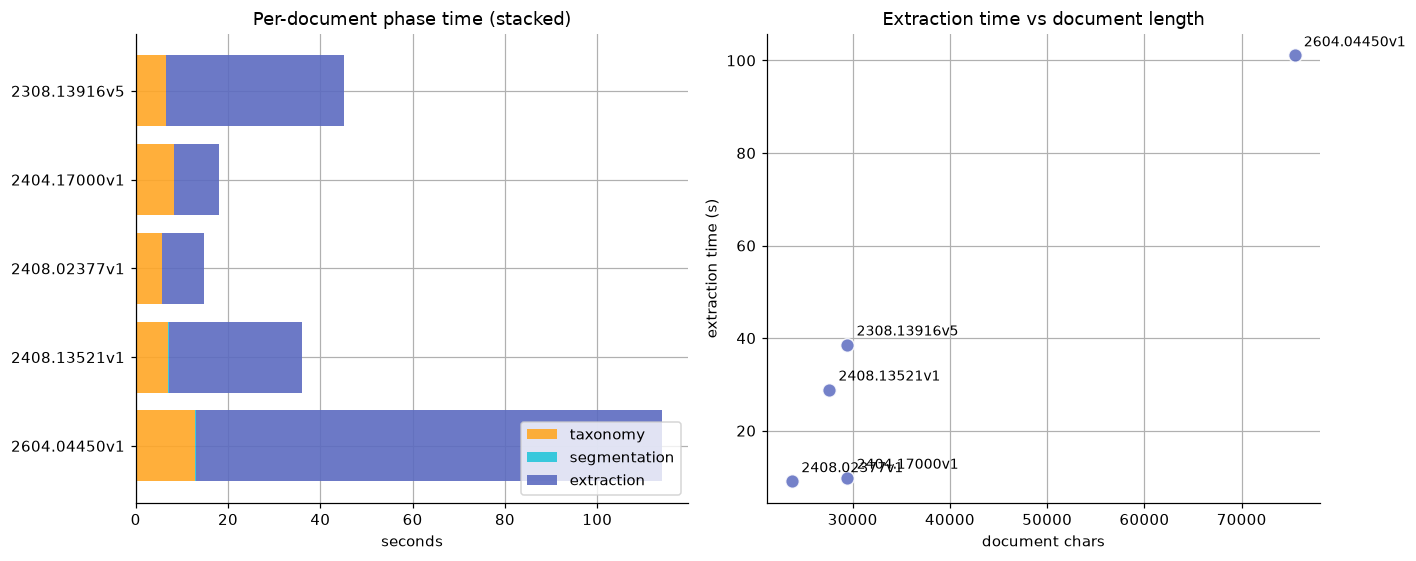

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

docs = [d.id for d in documents]
y = range(len(docs))

ax = axes[0]
parts = {
    "taxonomy": [per_doc_taxonomy_s[d] for d in docs],
    "segmentation": [per_doc_segment_s[d] for d in docs],
    "extraction": [per_doc_extract_s[d] for d in docs],
}
colors = {"taxonomy": "#ffa726", "segmentation": "#26c6da", "extraction": "#5c6bc0"}
left = [0] * len(docs)
for key in parts:
    vals = parts[key]
    ax.barh(list(y), vals, left=left, label=key, color=colors[key], alpha=0.9)
    left = [l + v for l, v in zip(left, vals)]
ax.set_yticks(list(y))
ax.set_yticklabels(docs)
ax.invert_yaxis()
ax.set_xlabel("seconds")
ax.set_title("Per-document phase time (stacked)")
ax.legend(loc="lower right")

ax = axes[1]
chars = [len(d.content) for d in documents]
ext = [per_doc_extract_s[d.id] for d in documents]
ax.scatter(chars, ext, color="#5c6bc0", s=80, alpha=0.85, edgecolors="white")
for doc_id, c, e in zip(docs, chars, ext):
    ax.annotate(doc_id, (c, e), xytext=(6, 6), textcoords="offset points", fontsize=9)
ax.set_xlabel("document chars")
ax.set_ylabel("extraction time (s)")
ax.set_title("Extraction time vs document length")

plt.tight_layout()
plt.show()


## Results — corpus graph summary

In [12]:
print(f"Total nodes: {summary['total_nodes']} (common {summary['common_nodes']} | unique {summary['unique_nodes']})")
print(f"Total edges: {summary['total_edges']} (common {summary['common_edges']} | unique {summary['unique_edges']})")
print()
for doc_id, per in summary["per_document"].items():
    print(
        f"  {doc_id}: {per['nodes_in_doc']} nodes, {per['unique_nodes']} unique "
        f"({per['novelty'] * 100:.0f}% novelty), {per['unique_edges']} unique edges"
    )


Total nodes: 1318 (common 65 | unique 1253)
Total edges: 255 (common 0 | unique 255)

  2308.13916v5: 283 nodes, 246 unique (87% novelty), 26 unique edges
  2404.17000v1: 312 nodes, 279 unique (89% novelty), 71 unique edges
  2408.02377v1: 182 nodes, 163 unique (90% novelty), 104 unique edges
  2408.13521v1: 311 nodes, 281 unique (90% novelty), 48 unique edges
  2604.04450v1: 317 nodes, 284 unique (90% novelty), 6 unique edges


## Save the report

Persists the environment, every phase time (and its per-document detail), the
graph summary and the artifact paths to a JSON file next to this notebook, so
the timings survive even if the cells are not re-run.

In [13]:
report = {
    "title": "Corpus demo — pipeline timing report",
    "environment": env,
    "phases_seconds": {
        k: timings[k]["total_s"]
        for k in list(phase_labels) + ["model_load"]
    },
    "phase_details": {
        k: {kk: vv for kk, vv in timings[k].items() if kk != "total_s"}
        for k in timings
    },
    "totals": {
        "pipeline_seconds": round(pipeline_total, 3),
        "n_documents": len(documents),
        "n_segments": n_segments,
        "workers": builder.workers,
    },
    "graph_summary": summary,
    "artifacts": {
        "corpus_json": str(export_json),
        "corpus_html": str(export_html),
    },
}

report_path = BACKEND / "reports" / f"corpus_timing_{env['git_short_commit']}.json"
report_path.write_text(json.dumps(report, indent=2, default=str))
print(f"Timing report saved to {report_path}")


Timing report saved to /Users/albertovillamanrique/repositories/kgraph/backend/reports/corpus_timing_2d91bd8.json
